<a href="https://colab.research.google.com/github/Mithilesh-Kr-Chaudhary/machine-learning-projects/blob/main/customer_churn_prediction_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Churn Prediction

Upload this notebook to [Google Colab](https://colab.research.google.com/), then run the cell below. When asked, upload a CSV containing historical customer data and a binary churn target (such as `Churn`, `Churned`, or `Exited`).

Saving Churn_Modelling (1).csv to Churn_Modelling (1) (1).csv
Loaded Churn_Modelling (1) (1).csv: 10,000 rows × 14 columns


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Target column: Exited
Removed identifier columns: ['CustomerId']
Churn rate: 20.4%
Logistic Regression : ROC-AUC 0.735 ± 0.019
Random Forest       : ROC-AUC 0.811 ± 0.020
Gradient Boosting    : ROC-AUC 0.853 ± 0.014

Selected model: Gradient Boosting
Test ROC-AUC: 0.855

Classification report at threshold 0.50:
              precision    recall  f1-score   support

    Retained      0.881     0.953     0.916      1593
     Churned      0.729     0.496     0.591       407

    accuracy                          0.860      2000
   macro avg      0.805     0.725     0.753      2000
weighted avg      0.850     0.860     0.849      2000



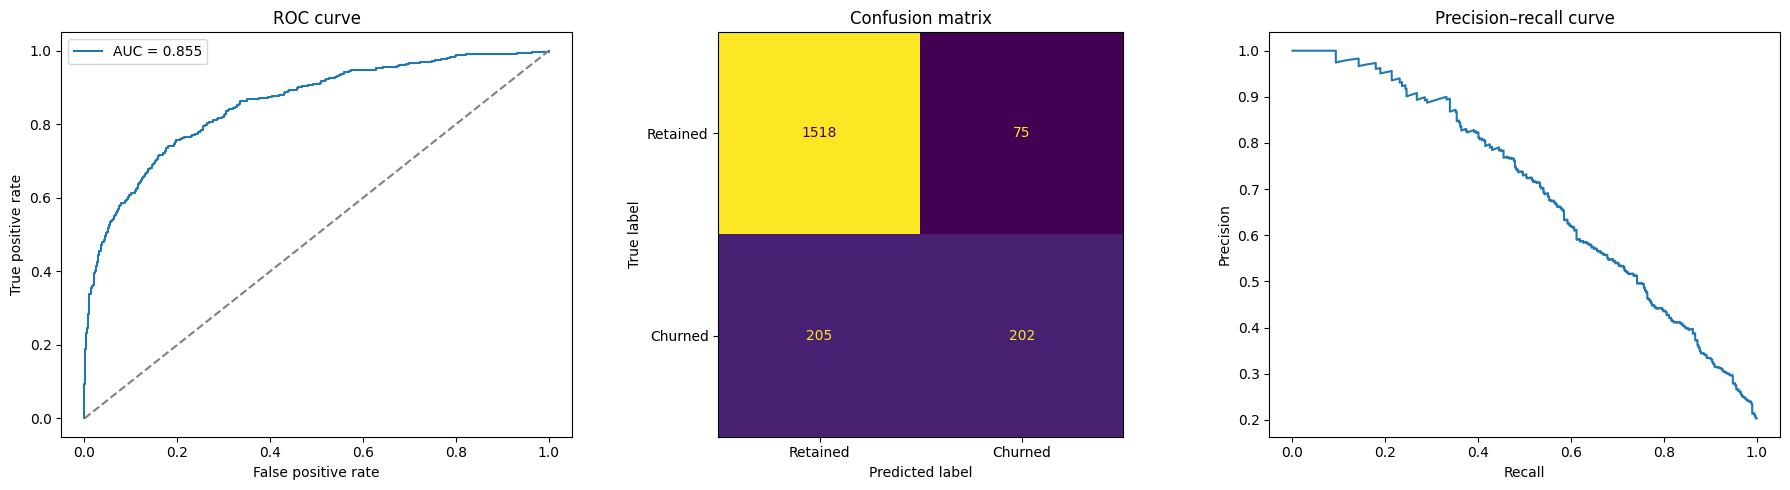

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved scored customers and reusable trained model.
Before deployment: exclude fields learned only after a customer churns (data leakage).


In [3]:
!pip -q install joblib

import io
import re
import warnings
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from google.colab import files
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, precision_recall_curve, roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
TARGET_COLUMN = None  # Example: 'Churn'. Leave None to detect automatically.
ID_COLUMN_HINTS = ('id', 'customerid', 'customer_id', 'accountnumber', 'account_number')

uploaded = files.upload()
if not uploaded:
    raise ValueError('Please upload a CSV file and rerun this cell.')
file_name, file_bytes = next(iter(uploaded.items()))
if not file_name.lower().endswith('.csv'):
    raise ValueError('Export the customer history as a CSV before using this notebook.')
df = pd.read_csv(io.BytesIO(file_bytes))
print(f'Loaded {file_name}: {df.shape[0]:,} rows × {df.shape[1]:,} columns')
display(df.head())

# 2) Identify the binary churn target and prevent identifier leakage
def find_target(frame, requested_target=None):
    if requested_target:
        if requested_target not in frame.columns:
            raise ValueError(f"TARGET_COLUMN '{requested_target}' is not in the CSV.")
        return requested_target
    normalized = {re.sub(r'[^a-z0-9]', '', c.lower()): c for c in frame.columns}
    for candidate in ('churn', 'churned', 'ischurned', 'exited', 'cancelled', 'canceled'):
        if candidate in normalized:
            return normalized[candidate]
    raise ValueError("Target not detected. Set TARGET_COLUMN to your binary churn-column name.")

target = find_target(df, TARGET_COLUMN)
print('Target column:', target)

def convert_to_binary(series):
    if pd.api.types.is_numeric_dtype(series) and set(series.dropna().unique()).issubset({0, 1}):
        return series.astype('int64')
    mapping = {
        'yes': 1, 'y': 1, 'true': 1, '1': 1, 'churn': 1, 'churned': 1,
        'exited': 1, 'cancelled': 1, 'canceled': 1,
        'no': 0, 'n': 0, 'false': 0, '0': 0, 'active': 0, 'retained': 0
    }
    result = series.astype(str).str.strip().str.lower().map(mapping)
    if result.isna().any():
        raise ValueError(f"Target must be binary; values include {series.dropna().unique()[:10]}.")
    return result.astype('int64')

y = convert_to_binary(df[target])
X = df.drop(columns=[target]).copy()
identifier_columns = [c for c in X.columns if re.sub(r'[^a-z0-9]', '', c.lower()) in ID_COLUMN_HINTS]
X = X.drop(columns=identifier_columns)
print('Removed identifier columns:', identifier_columns or 'None')
print('Churn rate: {:.1%}'.format(y.mean()))
if y.nunique() != 2 or y.value_counts().min() < 2:
    raise ValueError('Both churn classes need at least two observations.')

# Convert numeric-looking strings (for example, TotalCharges) to numbers.
for col in X.select_dtypes(include='object').columns:
    parsed = pd.to_numeric(X[col].astype(str).str.strip(), errors='coerce')
    if parsed.notna().mean() >= 0.90:
        X[col] = parsed

# 3) Hold out an unseen test set and define preprocessing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = [c for c in X_train.columns if c not in numeric_features]

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

models = {
    'Logistic Regression': LogisticRegression(max_iter=3000, class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(
        n_estimators=500, min_samples_leaf=3, class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1
    )
}

# 4) Compare Logistic Regression and Random Forest using five-fold ROC-AUC
pipelines = {name: Pipeline([('preprocessor', preprocessor), ('model', model)])
             for name, model in models.items()}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scores = {}
for name, pipeline in pipelines.items():
    cv_scores = cross_val_score(pipeline, X_train, y_train, scoring='roc_auc', cv=cv, n_jobs=-1)
    scores[name] = cv_scores
    print(f'{name:20s}: ROC-AUC {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')

# Gradient Boosting requires dense feature output.
dense_preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), categorical_features)
], sparse_threshold=0)
gb_pipeline = Pipeline([
    ('preprocessor', dense_preprocessor),
    ('model', HistGradientBoostingClassifier(
        learning_rate=0.08, max_iter=300, max_leaf_nodes=20,
        l2_regularization=1.0, random_state=RANDOM_STATE
    ))
])
gb_scores = cross_val_score(gb_pipeline, X_train, y_train, scoring='roc_auc', cv=cv, n_jobs=-1)
scores['Gradient Boosting'] = gb_scores
pipelines['Gradient Boosting'] = gb_pipeline
print(f'Gradient Boosting    : ROC-AUC {gb_scores.mean():.3f} ± {gb_scores.std():.3f}')

best_name = max(scores, key=lambda name: scores[name].mean())
best_model = pipelines[best_name]
print(f'\nSelected model: {best_name}')

# 5) Train best candidate and evaluate it only once on the test set
best_model.fit(X_train, y_train)
test_probabilities = best_model.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, test_probabilities)
threshold = 0.50  # Lower this when catching more likely churners matters more than outreach cost.
test_predictions = (test_probabilities >= threshold).astype(int)

print(f'Test ROC-AUC: {test_auc:.3f}')
print('\nClassification report at threshold {:.2f}:'.format(threshold))
print(classification_report(y_test, test_predictions, target_names=['Retained', 'Churned'], digits=3))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fpr, tpr, _ = roc_curve(y_test, test_probabilities)
axes[0].plot(fpr, tpr, label=f'AUC = {test_auc:.3f}')
axes[0].plot([0, 1], [0, 1], '--', color='grey')
axes[0].set(title='ROC curve', xlabel='False positive rate', ylabel='True positive rate')
axes[0].legend()
ConfusionMatrixDisplay.from_predictions(y_test, test_predictions, display_labels=['Retained', 'Churned'], ax=axes[1], colorbar=False)
axes[1].set_title('Confusion matrix')
precision, recall, _ = precision_recall_curve(y_test, test_probabilities)
axes[2].plot(recall, precision)
axes[2].set(title='Precision–recall curve', xlabel='Recall', ylabel='Precision')
plt.tight_layout()
plt.show()

# 6) Explain and export results
try:
    feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()
    estimator = best_model.named_steps['model']
    if hasattr(estimator, 'feature_importances_'):
        importance = estimator.feature_importances_
    elif hasattr(estimator, 'coef_'):
        importance = np.abs(estimator.coef_.ravel())
    else:
        importance = None
    if importance is not None:
        feature_importance = pd.DataFrame({'feature': feature_names, 'importance': importance})
        feature_importance = feature_importance.sort_values('importance', ascending=False).head(20)
        display(feature_importance)
        sns.barplot(data=feature_importance, x='importance', y='feature', color='#4C78A8')
        plt.title('Top churn drivers (model importance)')
        plt.show()
except Exception as exc:
    print('Feature-importance chart unavailable:', exc)

scored_customers = df.copy()
scored_customers['churn_risk_probability'] = best_model.predict_proba(X)[:, 1]
scored_customers['churn_risk_band'] = pd.cut(
    scored_customers['churn_risk_probability'],
    bins=[-0.01, 0.30, 0.60, 1.00], labels=['Low', 'Medium', 'High']
)
scored_customers.sort_values('churn_risk_probability', ascending=False).to_csv('customer_churn_scores.csv', index=False)
joblib.dump(best_model, 'customer_churn_model.joblib')
files.download('customer_churn_scores.csv')
files.download('customer_churn_model.joblib')

print('Saved scored customers and reusable trained model.')
print('Before deployment: exclude fields learned only after a customer churns (data leakage).')



